In [1]:
# ============================================
# 1. 필요한 라이브러리 불러오기
# ============================================

# 데이터 처리를 위한 라이브러리
import pandas as pd
import numpy as np

# Random Forest 분류 모델
from sklearn.ensemble import RandomForestClassifier

# 모델 성능 평가 지표
from sklearn.metrics import (
    accuracy_score,        # 정확도
    precision_score,       # 정밀도
    recall_score,          # 재현율
    f1_score,              # F1-score
    roc_auc_score,         # ROC-AUC
    confusion_matrix,      # 혼동행렬
    classification_report  # 클래스별 성능 확인
)

# 학습한 모델 저장
import joblib

print("라이브러리 로드 완료!")

라이브러리 로드 완료!


In [2]:
# ============================================
# 2. 전처리된 데이터 불러오기
# ============================================

# preprocess.ipynb에서 이미 전처리가 완료된
# train / validation / test 데이터를 사용
train = pd.read_csv("../data/processed/train.csv")
val = pd.read_csv("../data/processed/val.csv")
test = pd.read_csv("../data/processed/test.csv")

# 데이터 크기 확인
print("Train 데이터 크기 :", train.shape)
print("Validation 데이터 크기 :", val.shape)
print("Test 데이터 크기 :", test.shape)

Train 데이터 크기 : (2654, 82)
Validation 데이터 크기 : (885, 82)
Test 데이터 크기 : (885, 82)


In [3]:
# ============================================
# 3. Feature(X)와 Target(y) 분리
# ============================================

# 모델 입력값 X
# target 컬럼을 제외한 나머지 81개 Feature 사용
X_train = train.drop(columns="target")
X_val = val.drop(columns="target")
X_test = test.drop(columns="target")

# 모델이 예측해야 하는 정답 y
# 0 : Non-Dropout
# 1 : Dropout
y_train = train["target"]
y_val = val["target"]
y_test = test["target"]

# 데이터 크기 확인
print("X_train :", X_train.shape)
print("y_train :", y_train.shape)

print("X_val   :", X_val.shape)
print("y_val   :", y_val.shape)

print("X_test  :", X_test.shape)
print("y_test  :", y_test.shape)

X_train : (2654, 81)
y_train : (2654,)
X_val   : (885, 81)
y_val   : (885,)
X_test  : (885, 81)
y_test  : (885,)


In [4]:
# ============================================
# 4. Target 클래스 분포 확인
# ============================================

# 학습 데이터의 클래스 개수 확인
print("Target 개수")
print(y_train.value_counts())

# 학습 데이터의 클래스 비율 확인
print("\nTarget 비율")
print(y_train.value_counts(normalize=True))

Target 개수
target
0    1802
1     852
Name: count, dtype: int64

Target 비율
target
0    0.678975
1    0.321025
Name: proportion, dtype: float64


In [5]:
# ============================================
# 5. Random Forest 모델 생성
# ============================================

# Random Forest
# → 여러 개의 Decision Tree를 학습한 뒤
#   각 트리의 예측 결과를 종합하여 최종 분류를 수행하는 앙상블 모델

rf_model = RandomForestClassifier(
    
    # 생성할 Decision Tree 개수
    # 트리가 많을수록 일반적으로 안정적인 결과를 얻을 수 있지만
    # 학습 시간이 증가할 수 있음
    n_estimators=200,
    
    # 실행할 때마다 동일한 결과를 재현하기 위한 설정
    random_state=42,
    
    # CPU 코어를 모두 사용하여 학습 속도 향상
    n_jobs=-1
)

print("Random Forest 모델 생성 완료!")

Random Forest 모델 생성 완료!


In [6]:
# ============================================
# 6. Random Forest 모델 학습
# ============================================

# X_train과 y_train을 이용하여
# 여러 개의 Decision Tree를 학습
rf_model.fit(X_train, y_train);

print("Random Forest 학습 완료!")

Random Forest 학습 완료!


In [7]:
# ============================================
# 7. Validation 데이터 예측
# ============================================

# 최종 클래스 예측
# 0 : Non-Dropout
# 1 : Dropout
y_val_pred_rf = rf_model.predict(X_val)

# Dropout(1)일 확률 예측
# ROC-AUC 계산 등에 사용
y_val_proba_rf = rf_model.predict_proba(X_val)[:, 1]

print("Validation 데이터 예측 완료!")

Validation 데이터 예측 완료!


In [8]:
# ============================================
# 8. Validation 데이터 모델 성능 평가
# ============================================

# Accuracy
rf_accuracy = accuracy_score(
    y_val,
    y_val_pred_rf
)

# Precision
rf_precision = precision_score(
    y_val,
    y_val_pred_rf
)

# Recall
rf_recall = recall_score(
    y_val,
    y_val_pred_rf
)

# F1-score
rf_f1 = f1_score(
    y_val,
    y_val_pred_rf
)

# ROC-AUC
rf_roc_auc = roc_auc_score(
    y_val,
    y_val_proba_rf
)


print("===== Random Forest Validation 성능 =====")
print(f"Accuracy  : {rf_accuracy:.4f}")
print(f"Precision : {rf_precision:.4f}")
print(f"Recall    : {rf_recall:.4f}")
print(f"F1-score  : {rf_f1:.4f}")
print(f"ROC-AUC   : {rf_roc_auc:.4f}")

===== Random Forest Validation 성능 =====
Accuracy  : 0.8814
Precision : 0.8462
Recall    : 0.7719
F1-score  : 0.8073
ROC-AUC   : 0.9266


In [9]:
# ============================================
# 9. Random Forest Validation Confusion Matrix
# ============================================

# 실제값과 Random Forest 예측값을 비교하여
# Confusion Matrix 생성
rf_cm = confusion_matrix(
    y_val,
    y_val_pred_rf
)

# TN, FP, FN, TP 값으로 분리
tn, fp, fn, tp = rf_cm.ravel()

print("===== Random Forest Confusion Matrix =====")
print(rf_cm)

print("\n===== 예측 결과 상세 =====")

# 실제 Non-Dropout을 정확하게 Non-Dropout으로 예측
print(f"TN - 정확히 Non-Dropout 예측  : {tn}명")

# 실제 Non-Dropout인데 Dropout으로 잘못 예측
print(f"FP - 잘못 Dropout으로 예측    : {fp}명")

# 실제 Dropout인데 Non-Dropout으로 잘못 예측
# → 중도이탈 학생을 놓친 경우이므로 중요하게 확인
print(f"FN - 놓친 Dropout 학생        : {fn}명")

# 실제 Dropout을 정확하게 Dropout으로 예측
print(f"TP - 정확히 찾은 Dropout 학생 : {tp}명")

===== Random Forest Confusion Matrix =====
[[560  40]
 [ 65 220]]

===== 예측 결과 상세 =====
TN - 정확히 Non-Dropout 예측  : 560명
FP - 잘못 Dropout으로 예측    : 40명
FN - 놓친 Dropout 학생        : 65명
TP - 정확히 찾은 Dropout 학생 : 220명


In [10]:
# ============================================
# 10. Random Forest Classification Report
# ============================================

# 클래스별 Precision, Recall, F1-score 확인
#
# 0 : Non-Dropout
# 1 : Dropout
#
# 프로젝트 목적상 특히 Dropout(1)의
# Recall과 F1-score를 중요하게 확인
rf_report = classification_report(
    y_val,
    y_val_pred_rf,
    target_names=["Non-Dropout", "Dropout"]
)

print("===== Random Forest Classification Report =====")
print(rf_report)

===== Random Forest Classification Report =====
              precision    recall  f1-score   support

 Non-Dropout       0.90      0.93      0.91       600
     Dropout       0.85      0.77      0.81       285

    accuracy                           0.88       885
   macro avg       0.87      0.85      0.86       885
weighted avg       0.88      0.88      0.88       885



In [11]:
# ============================================
# 11. Random Forest 하이퍼파라미터 튜닝
#     - RandomizedSearchCV 사용
# ============================================

# 여러 하이퍼파라미터 조합 중 일부를 무작위로 탐색하여
# 좋은 조합을 찾기 위한 RandomizedSearchCV
from sklearn.model_selection import RandomizedSearchCV


# ============================================
# 탐색할 하이퍼파라미터 범위 설정
# ============================================

param_distributions = {

    # Random Forest를 구성하는 Decision Tree 개수
    "n_estimators": [100, 200, 300, 500],

    # 각 Decision Tree가 성장할 수 있는 최대 깊이
    # None은 깊이를 제한하지 않는다는 의미
    "max_depth": [None, 5, 10, 15, 20],

    # 하나의 노드를 두 개로 나누기 위해 필요한
    # 최소 데이터 개수
    "min_samples_split": [2, 5, 10],

    # 하나의 Leaf Node가 가져야 하는
    # 최소 데이터 개수
    "min_samples_leaf": [1, 2, 4],

    # 각 Tree에서 분할할 때 사용할 Feature 개수 결정 방식
    "max_features": ["sqrt", "log2", None],

    # 클래스 불균형에 대한 가중치
    # None과 balanced를 모두 비교
    "class_weight": [None, "balanced"]
}


# ============================================
# Random Forest 기본 모델 생성
# ============================================

rf_search_model = RandomForestClassifier(
    random_state=42,

    # CPU 코어를 모두 사용하여 학습 속도 향상
    n_jobs=-1
)


# ============================================
# RandomizedSearchCV 설정
# ============================================

rf_random_search = RandomizedSearchCV(

    # 튜닝할 모델
    estimator=rf_search_model,

    # 위에서 정의한 하이퍼파라미터 후보
    param_distributions=param_distributions,

    # 무작위로 테스트할 조합 개수
    # 전체 조합을 모두 확인하지 않고 30개 조합을 탐색
    n_iter=30,

    # 5-Fold Cross Validation
    # Train 데이터를 5개로 나누어 반복적으로 검증
    cv=5,

    # 이번 프로젝트에서는
    # Precision과 Recall의 균형을 고려하여
    # F1-score가 높은 조합을 선택
    scoring="f1",

    # CPU 코어 모두 사용
    n_jobs=-1,

    # 실행 과정 출력
    verbose=1,

    # 실행할 때마다 동일한 조합을 탐색하도록 설정
    random_state=42
)


# ============================================
# Train 데이터로 하이퍼파라미터 탐색
# ============================================

# Test 데이터는 절대 사용하지 않음
# RandomizedSearchCV 내부에서 Train 데이터만 이용하여
# Cross Validation을 수행
rf_random_search.fit(
    X_train,
    y_train
);

print("Random Forest 하이퍼파라미터 탐색 완료!")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Random Forest 하이퍼파라미터 탐색 완료!


In [12]:
# ============================================
# 12. 최적 하이퍼파라미터 확인
# ============================================

# RandomizedSearchCV가 찾은
# 가장 높은 Cross Validation F1-score 출력
print(
    "Best CV F1-score :",
    round(rf_random_search.best_score_, 4)
)

print("\n===== Best Parameters =====")

# 최적 하이퍼파라미터 출력
for parameter, value in rf_random_search.best_params_.items():
    print(f"{parameter} : {value}")


# 최적 하이퍼파라미터가 적용된
# Random Forest 모델 가져오기
rf_best_model = rf_random_search.best_estimator_

print("\n최적 Random Forest 모델 저장 완료!")

Best CV F1-score : 0.7837

===== Best Parameters =====
n_estimators : 500
min_samples_split : 5
min_samples_leaf : 2
max_features : sqrt
max_depth : 20
class_weight : balanced

최적 Random Forest 모델 저장 완료!


In [13]:
# ============================================
# 13. 튜닝된 Random Forest Validation 성능 평가
# ============================================

# RandomizedSearchCV를 통해 찾은
# 최적 Random Forest 모델로 Validation 데이터 예측
#
# rf_best_model에는 아래 최적 파라미터가 적용되어 있음
# n_estimators     : 500
# min_samples_split: 5
# min_samples_leaf : 2
# max_features     : sqrt
# max_depth        : 20
# class_weight     : balanced

# Validation 데이터의 최종 클래스 예측
# 0 : Non-Dropout
# 1 : Dropout
y_val_pred_rf_best = rf_best_model.predict(X_val)


# Validation 데이터의 Dropout(1) 확률 예측
# ROC-AUC 계산 및 이후 Threshold 조정에 사용
y_val_proba_rf_best = rf_best_model.predict_proba(X_val)[:, 1]


# ============================================
# 성능 지표 계산
# ============================================

# Accuracy
rf_best_accuracy = accuracy_score(
    y_val,
    y_val_pred_rf_best
)

# Precision
rf_best_precision = precision_score(
    y_val,
    y_val_pred_rf_best
)

# Recall
# 실제 Dropout 학생을 얼마나 많이 찾아냈는지 확인
rf_best_recall = recall_score(
    y_val,
    y_val_pred_rf_best
)

# F1-score
# Precision과 Recall의 균형 확인
rf_best_f1 = f1_score(
    y_val,
    y_val_pred_rf_best
)

# ROC-AUC
# Dropout / Non-Dropout을 구분하는 능력 확인
rf_best_roc_auc = roc_auc_score(
    y_val,
    y_val_proba_rf_best
)


# ============================================
# 결과 출력
# ============================================

print("===== Tuned Random Forest Validation 성능 =====")
print(f"Accuracy  : {rf_best_accuracy:.4f}")
print(f"Precision : {rf_best_precision:.4f}")
print(f"Recall    : {rf_best_recall:.4f}")
print(f"F1-score  : {rf_best_f1:.4f}")
print(f"ROC-AUC   : {rf_best_roc_auc:.4f}")

===== Tuned Random Forest Validation 성능 =====
Accuracy  : 0.8746
Precision : 0.7862
Recall    : 0.8386
F1-score  : 0.8115
ROC-AUC   : 0.9289


In [14]:
# ============================================
# 14. Baseline vs Tuned Random Forest 비교
# ============================================

# 동일한 Validation 데이터를 기준으로
# 기본 모델과 튜닝 모델의 성능을 비교

rf_comparison = pd.DataFrame({
    "Model": [
        "Random Forest (Baseline)",
        "Random Forest (Tuned)"
    ],

    "Accuracy": [
        rf_accuracy,
        rf_best_accuracy
    ],

    "Precision": [
        rf_precision,
        rf_best_precision
    ],

    "Recall": [
        rf_recall,
        rf_best_recall
    ],

    "F1-score": [
        rf_f1,
        rf_best_f1
    ],

    "ROC-AUC": [
        rf_roc_auc,
        rf_best_roc_auc
    ]
})

# 소수점 넷째 자리까지 출력
rf_comparison.round(4)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Random Forest (Baseline),0.8814,0.8462,0.7719,0.8073,0.9266
1,Random Forest (Tuned),0.8746,0.7862,0.8386,0.8115,0.9289


In [15]:
# ============================================
# 15. Tuned Random Forest Threshold 조정
# ============================================

# 기본 Threshold=0.50 주변의 값을 비교하여
# Precision / Recall / F1-score의 균형이
# 더 좋아지는 지점이 있는지 확인
#
# Tuned Random Forest는 이미 Recall이 높은 편이므로
# 0.40~0.60 범위를 비교

thresholds = [
    0.40,
    0.45,
    0.50,
    0.55,
    0.60
]

rf_threshold_results = []


# 각 Threshold별 성능 계산
for threshold in thresholds:

    # Tuned Random Forest가 예측한 Dropout 확률에
    # 현재 Threshold를 적용
    #
    # 확률 >= Threshold → 1 (Dropout)
    # 확률 < Threshold  → 0 (Non-Dropout)
    y_val_pred_threshold = (
        y_val_proba_rf_best >= threshold
    ).astype(int)


    # Accuracy
    threshold_accuracy = accuracy_score(
        y_val,
        y_val_pred_threshold
    )

    # Precision
    threshold_precision = precision_score(
        y_val,
        y_val_pred_threshold
    )

    # Recall
    threshold_recall = recall_score(
        y_val,
        y_val_pred_threshold
    )

    # F1-score
    threshold_f1 = f1_score(
        y_val,
        y_val_pred_threshold
    )

    # ROC-AUC는 Threshold가 아니라
    # 예측 확률 자체를 이용하므로 모든 행에서 동일
    threshold_roc_auc = roc_auc_score(
        y_val,
        y_val_proba_rf_best
    )


    # 계산 결과 저장
    rf_threshold_results.append({
        "Threshold": threshold,
        "Accuracy": threshold_accuracy,
        "Precision": threshold_precision,
        "Recall": threshold_recall,
        "F1-score": threshold_f1,
        "ROC-AUC": threshold_roc_auc
    })


# DataFrame으로 변환
rf_threshold_comparison = pd.DataFrame(
    rf_threshold_results
)

# 소수점 넷째 자리까지 출력
rf_threshold_comparison.round(4)

,Threshold,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,0.40,0.8429,0.7051,0.8807,0.7832,0.9289
1,0.45,0.8554,0.7372,0.8561,0.7922,0.9289
2,0.50,0.8746,0.7862,0.8386,0.8115,0.9289
3,0.55,0.8791,0.8112,0.8140,0.8126,0.9289
4,0.60,0.8814,0.8383,0.7825,0.8094,0.9289


In [16]:
# ============================================
# 16. Random Forest 최종 Threshold 설정
# ============================================

# Validation 데이터에서 Threshold를 비교한 결과,
# Threshold=0.55에서 Precision과 Recall의 균형이 가장 좋고
# F1-score도 가장 높은 0.8126을 기록함
#
# Threshold=0.50
# Precision : 0.7862
# Recall    : 0.8386
# F1-score  : 0.8115
#
# Threshold=0.55
# Precision : 0.8112
# Recall    : 0.8140
# F1-score  : 0.8126
#
# 따라서 전체적인 분류 성능과
# 중도이탈 학생 탐지 성능의 균형을 고려하여
# 최종 Threshold를 0.55로 선정

rf_final_threshold = 0.55

print(f"Random Forest 최종 Threshold : {rf_final_threshold}")

Random Forest 최종 Threshold : 0.55


In [17]:
# ============================================
# 17. Random Forest 최종 Test 성능 평가
# ============================================

# 최종 튜닝된 Random Forest 모델로
# Test 데이터의 Dropout(1) 확률 예측
y_test_proba_rf = rf_best_model.predict_proba(X_test)[:, 1]

# Validation에서 선택한 최종 Threshold=0.55 적용
y_test_pred_rf = (
    y_test_proba_rf >= rf_final_threshold
).astype(int)

# 성능 지표 계산
rf_test_accuracy = accuracy_score(
    y_test,
    y_test_pred_rf
)

rf_test_precision = precision_score(
    y_test,
    y_test_pred_rf
)

rf_test_recall = recall_score(
    y_test,
    y_test_pred_rf
)

rf_test_f1 = f1_score(
    y_test,
    y_test_pred_rf
)

rf_test_roc_auc = roc_auc_score(
    y_test,
    y_test_proba_rf
)

# 결과 출력
print("===== Random Forest 최종 Test 성능 =====")
print(f"Threshold : {rf_final_threshold:.2f}")
print(f"Accuracy  : {rf_test_accuracy:.4f}")
print(f"Precision : {rf_test_precision:.4f}")
print(f"Recall    : {rf_test_recall:.4f}")
print(f"F1-score  : {rf_test_f1:.4f}")
print(f"ROC-AUC   : {rf_test_roc_auc:.4f}")

===== Random Forest 최종 Test 성능 =====
Threshold : 0.55
Accuracy  : 0.8915
Precision : 0.8456
Recall    : 0.8099
F1-score  : 0.8273
ROC-AUC   : 0.9349


In [18]:
# ==========================================
# Random Forest Feature Importance Top 10
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt
import joblib

# 저장된 최종 모델 불러오기
model_data = joblib.load("../models/random_forest.joblib")

# joblib 저장 형태에 따라 모델 꺼내기
if isinstance(model_data, dict):
    model = model_data.get("model")
else:
    model = model_data

# Feature 이름
feature_names = X_train.columns

# Random Forest Feature Importance
importances = model.feature_importances_

# DataFrame 생성
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})

# 중요도 높은 순서로 정렬
importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
).reset_index(drop=True)

# Top 10
top10_rf = importance_df.head(10)

print("Random Forest Feature Importance Top 10")
display(top10_rf)

Random Forest Feature Importance Top 10


,feature,importance
0,num__sem2_approval_rate,0.131186
1,num__Curricular units 2nd sem (approved),0.108240
2,num__sem1_approval_rate,0.098014
3,num__Curricular units 2nd sem (grade),0.080297
4,num__Curricular units 1st sem (approved),0.059122
5,num__Curricular units 1st sem (grade),0.047980
6,remainder__financial_risk_score,0.042798
7,remainder__Tuition fees up to date,0.038413
8,num__grade_change,0.036352
9,num__Age at enrollment,0.031950


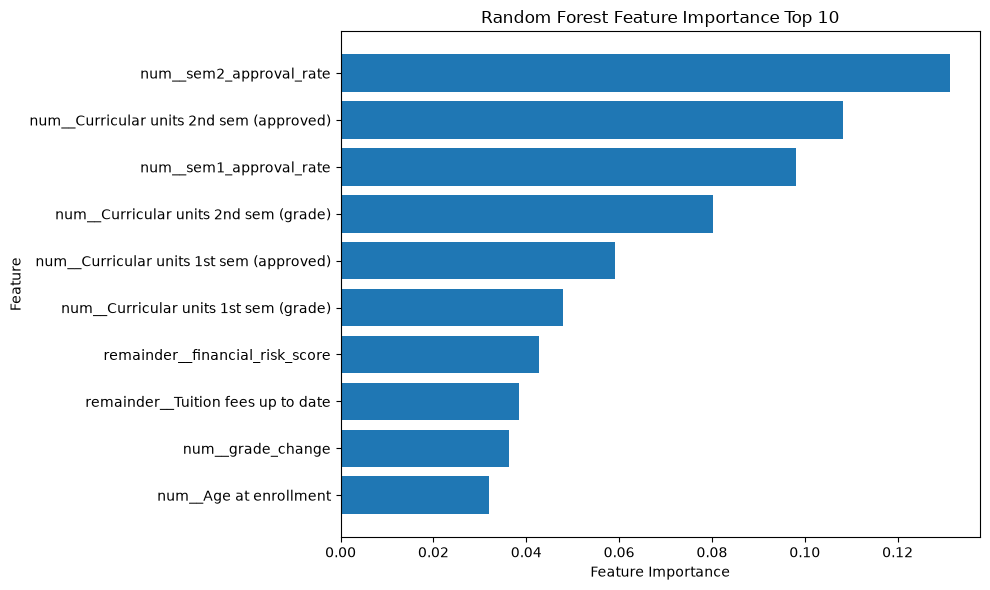

In [19]:
# CSV 저장
top10_rf.to_csv(
    "../reports/random_forest_importance.csv",
    index=False,
    encoding="utf-8-sig"
)

# 그래프
plt.figure(figsize=(10, 6))

plot_df = top10_rf.sort_values("importance")

plt.barh(
    plot_df["feature"],
    plot_df["importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance Top 10")

plt.tight_layout()

plt.savefig(
    "../reports/random_forest_importance_top10.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()